# Quantum-Assisted Machine Learning Framework for Wildlife Conservation and Threat Detection
Final integrated notebook.

## Install Required Libraries

In [1]:
!pip install qiskit qiskit-machine-learning torch torchvision librosa ultralytics scikit-learn opencv-python matplotlib

## Import Libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer import Aer

import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image

import librosa
from sklearn.svm import SVC
from ultralytics import YOLO


## Dataset Paths

In [3]:

train_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\train\images"
train_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\train\labels"

valid_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\valid\images"
valid_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\valid\labels"

test_images = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\test\images"
test_labels = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\archive\test\labels"

audio_dataset = r"C:\Users\KIIT0001\Desktop\Riju\quantum computing\code\Audio"


## CNN Feature Extraction

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT
cnn_model = resnet18(weights=weights)
cnn_model = torch.nn.Sequential(*list(cnn_model.children())[:-1])
cnn_model.to(device)
cnn_model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def extract_cnn_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = cnn_model(image)

    features = features.view(-1).cpu().numpy()
    return features[:4]


## Audio MFCC Extraction

In [5]:
def extract_audio_features(audio_path):

    y, sr = librosa.load(audio_path)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    mfcc_mean = np.mean(mfcc.T, axis=0)

    return mfcc_mean[:4]


## Dataset Loader

In [20]:
def load_dataset(image_dir, label_dir, limit=50):

    X, y = [], []
    count = 0

    for file in os.listdir(image_dir):

        if file.endswith(".jpg") or file.endswith(".png"):

            img_path = os.path.join(image_dir, file)

            label_file = file.replace(".jpg",".txt").replace(".png",".txt")
            label_path = os.path.join(label_dir, label_file)

            if os.path.exists(label_path):

                with open(label_path,"r") as f:
                    class_id = int(f.readline().split()[0])

            else:
                # default label if missing
                class_id = 0

            X.append(extract_cnn_features(img_path))
            y.append(class_id)

            count += 1
            if count >= limit:
                break

    return np.array(X), np.array(y)

## Load Image Dataset

In [21]:
X_train, y_train = load_dataset(train_images, train_labels)
X_valid, y_valid = load_dataset(valid_images, valid_labels)
X_test, y_test = load_dataset(test_images, test_labels)

print(X_train.shape, X_test.shape)


(50, 4) (50, 4)


## Feature Scaling

In [22]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)


## Limit Dataset Size

In [23]:
X_train = X_train[:20]
y_train = y_train[:20]

X_test = X_test[:10]
y_test = y_test[:10]


## Binary Labels

In [24]:
y_train = y_train % 2
y_test = y_test % 2


## Load Audio Dataset

In [25]:
def load_audio_dataset(audio_dir, limit=20):

    X_audio = []
    count = 0

    for root, dirs, files in os.walk(audio_dir):

        for file in files:

            if file.endswith(".wav"):

                audio_path = os.path.join(root, file)

                features = extract_audio_features(audio_path)

                X_audio.append(features)

                count += 1

                if count >= limit:
                    break

        if count >= limit:
            break

    return np.array(X_audio)

In [26]:
X_audio = load_audio_dataset(audio_dataset)

print("X_train shape:", X_train.shape)
print("X_audio shape:", X_audio.shape)

X_train shape: (20, 4)
X_audio shape: (20, 4)


## Combine Image and Audio Features

In [28]:
# find minimum samples separately
min_train = min(len(X_train), len(X_audio))
min_test = min(len(X_test), len(X_audio))

# combine train
X_train = np.concatenate(
    [X_train[:min_train], X_audio[:min_train]],
    axis=1
)

# combine test
X_test = np.concatenate(
    [X_test[:min_test], X_audio[:min_test]],
    axis=1
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (20, 12)
Test shape: (10, 8)


In [29]:
print("X_train shape:", X_train.shape)
print("X_audio shape:", X_audio.shape)

X_train shape: (20, 12)
X_audio shape: (20, 4)


## Classical Baseline

In [31]:
# find matching sizes
min_train = min(len(X_train), len(X_audio))
min_test = min(len(X_test), len(X_audio))

# combine features
X_train = np.concatenate([X_train[:min_train], X_audio[:min_train]], axis=1)
X_test = np.concatenate([X_test[:min_test], X_audio[:min_test]], axis=1)

print("Combined train shape:", X_train.shape)
print("Combined test shape:", X_test.shape)

# IMPORTANT: reduce features for quantum + classical models
X_train = X_train[:, :4]
X_test = X_test[:, :4]

print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)

Combined train shape: (20, 16)
Combined test shape: (10, 12)
Final train shape: (20, 4)
Final test shape: (10, 4)


## Quantum Support Vector Machine

In [32]:
feature_map = ZZFeatureMap(feature_dimension=4, reps=2)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(X_train, y_train)

print("QSVM Accuracy:", qsvc.score(X_test, y_test))


QSVM Accuracy: 0.6


## Variational Quantum Circuit

In [33]:
num_qubits = 4

feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2)
ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2)

backend = Aer.get_backend("aer_simulator_statevector")

optimizer = COBYLA(maxiter=100)

vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, quantum_instance=backend)

vqc.fit(X_train, y_train)

print("Train Accuracy:", vqc.score(X_train, y_train))
print("Test Accuracy:", vqc.score(X_test, y_test))


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_3632\2071115671.py:10: DeprecationWarning: The quantum_instance argument is deprecated as of version 0.5.0 and will be removed no sooner than 3 months after the release. Instead use the sampler argument.
  vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, quantum_instance=backend)


Train Accuracy: 0.75
Test Accuracy: 0.6


## Confusion Matrix

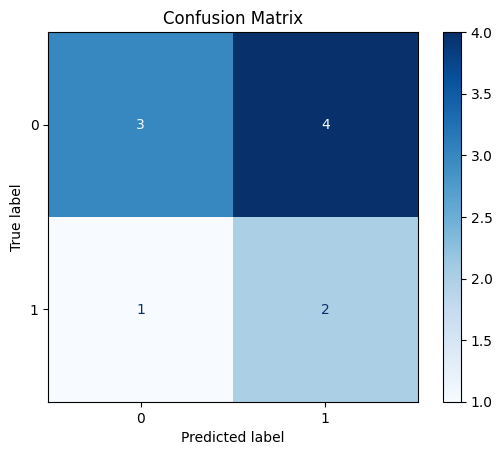

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = vqc.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

<b style="font-size: 20px;">Accuracy Graph</b>



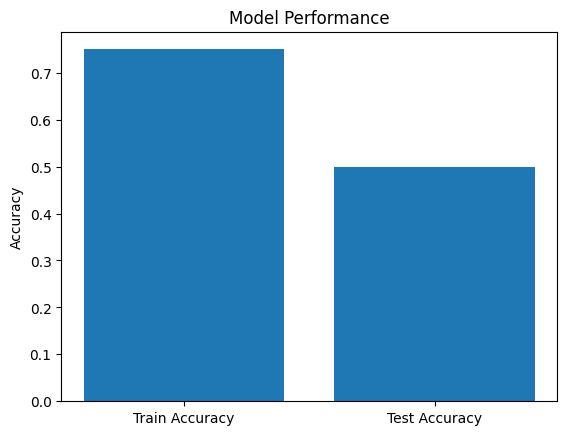

In [42]:
train_acc = vqc.score(X_train, y_train)
test_acc = vqc.score(X_test, y_test)

plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])

plt.ylabel("Accuracy")
plt.title("Model Performance")

plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

<b style="font-size: 20px;">Feature Distribution Grapht</b>


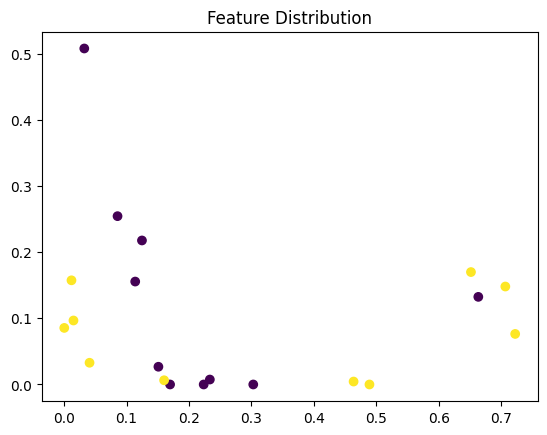

In [43]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)

plt.title("Feature Distribution")

plt.savefig("feature_distribution.png", dpi=300)

plt.show()

## Evaluation Metrics

In [35]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


Precision: 0.3333333333333333
Recall: 0.6666666666666666
F1 Score: 0.4444444444444444
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.33      0.67      0.44         3

    accuracy                           0.50        10
   macro avg       0.54      0.55      0.49        10
weighted avg       0.62      0.50      0.52        10



## Quantum Circuit Visualization

In [37]:
import matplotlib.pyplot as plt

vqc_circuit = feature_map.compose(ansatz)

fig = vqc_circuit.draw(
    output="mpl",
    fold=30
)

# show circuit
plt.show()

# save circuit diagram
fig.savefig("quantum_vqc_circuit.png", dpi=300)

## Threat Detection

In [38]:
threat_model = YOLO("yolov8n.pt")

def detect_threat(image_path):

    results = threat_model(image_path)

    for r in results:
        for box in r.boxes:
            if int(box.cls) == 0:
                return "Human detected - Possible Poaching Threat"

    return "No Threat"
